# 1- HOUSE PRICE PREDICTOR — Clean Structured Version
1️_ Project Introduction
The Goal

Predict house prices (medv) using regression based on the Boston Housing Dataset.

The dataset contains housing information from:

Boston

from the 1970s.

# 2-Importing Important Libraries

In [45]:
# Core
import pandas as pd
import numpy as np
import os
import platform

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import torch
import torch.nn as nn
import torch.utils.data as D
import lightning as L


# Metrics
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from pytorch_lightning import Trainer

torch.manual_seed(0)

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("Lightning:", L.__version__)

Python: 3.14.3
Torch: 2.10.0+cpu
Lightning: 2.6.1


# 3- Data Analysis

In [46]:
df = pd.read_csv("BostonHousing.csv")

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


# Basic Information

In [47]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# Check Missing Values

In [48]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

# Distribution of Target Variable

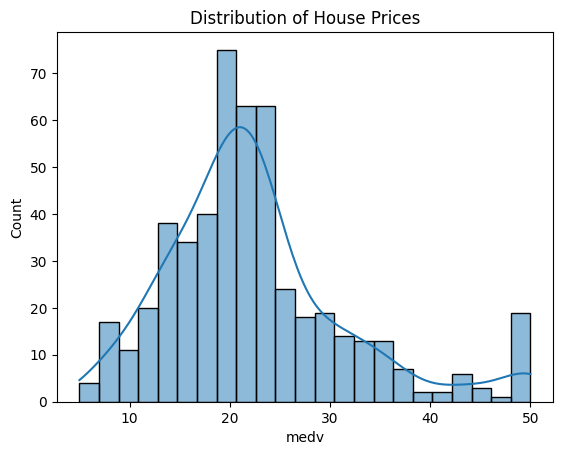

In [49]:
plt.figure()
sns.histplot(df["medv"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# 4- Correlation Analysis

Which features influence house price most.


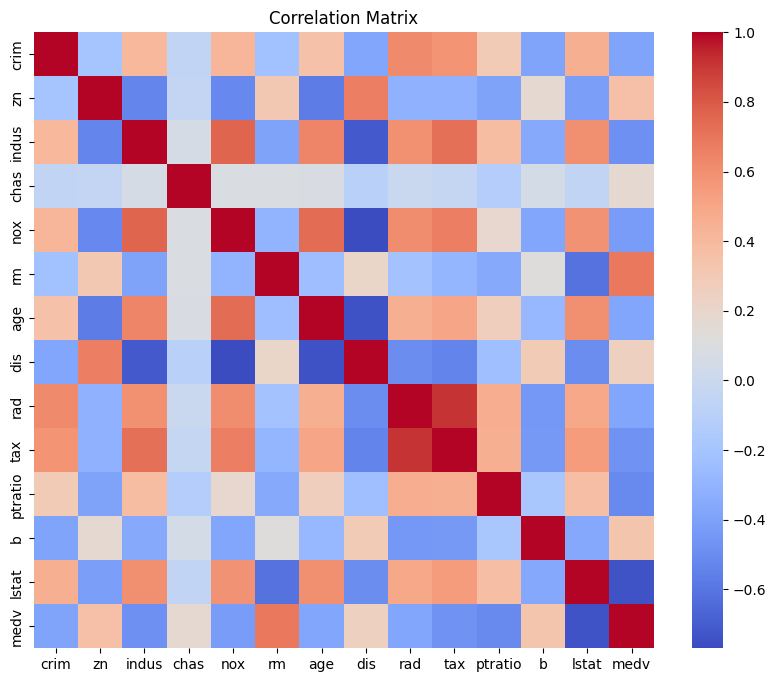

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Key Insights from the Matrix

Biggest Positive Influence: rm (average rooms) at 0.70. More rooms strongly correlate with higher home values.

Biggest Negative Influence: lstat (% lower status) at -0.74. This is the strongest negative factor. ptratio (pupil-teacher ratio) at -0.51 also shows that worse schools correlate with lower prices.

Red Flags (Multicollinearity): Notice how high rad and tax correlate (0.91). If you were building a predictive model, you would likely not use both of these together, as they are essentially telling the same story and would distort the model's results.

# 5- Normality Check

Regression models often assume normal distribution.

In [51]:
from scipy.stats import normaltest

stat, p = normaltest(df["medv"])
print("p-value:", p)

p-value: 1.7583188871696098e-20


# The house prices (medv) are not normally distributed.

This is expected for housing data because:

   There are a few very expensive houses

   A few very cheap houses

   Most houses lie near the average price 

# Handling Non-Normal Data

In [52]:
df["medv_log"] = np.log(df["medv"])

# 6- Feature Scaling

In [53]:
scaler = StandardScaler()

# Separate features and target
X = df.drop(columns=["medv", "medv_log"])
y = df["medv_log"]

# Convert to float
X = X.astype(float)

# Scale features
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine with target again
df_scaled = pd.concat([X_scaled, y], axis=1)

First, the dataset is split into features (X) and the target variable (y). The feature values are converted to float to avoid datatype issues. Then StandardScaler is applied to standardize the features so they have a mean of 0 and a standard deviation of 1, which helps the model train more effectively. Finally, the scaled features are converted back to a DataFrame and combined with the target variable to create the final dataset used for training.

# 7- Creating a Tensor Dataset

Neural networks do not understand Pandas DataFrames.
They work with PyTorch tensors.

Therefore, the data must be converted:

DataFrame → NumPy array → PyTorch Tensor

In [54]:

class TabularDataset(D.TensorDataset):
    
    def __init__(self, dataframe):
        
        rows = dataframe.values.astype(np.float32)
        data = torch.tensor(rows)
        
        super().__init__(data[:, :-1], data[:, -1])

    def num_features(self):
        return self[0][0].shape[0]

(features, target)

# 8- Train / Validation / Test Split

I will split the dataset:

  60% training

  30% validation

  10% testing

In [55]:

dataset = TabularDataset(df)

train_size = int(0.6 * len(dataset))
val_size = int(0.3 * len(dataset))
test_size = len(dataset) - train_size - val_size

train, val, test = D.random_split(dataset, [train_size, val_size, test_size])

After splitting, DataLoaders are created. DataLoaders load the data in small batches, which improves training efficiency.

Create dataloaders:

In [56]:
train_loader = D.DataLoader(train, batch_size=32, shuffle=True)
val_loader = D.DataLoader(val, batch_size=32)
test_loader = D.DataLoader(test, batch_size=32)

# 9- Define Neural Network

Architecture: Feedforward NN with 2 hidden layers.

Loss: MSE for regression

Optimizer: Adam

In [57]:

class RegressionModel(L.LightningModule):

    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x).view(-1)

    def training_step(self, batch, batch_idx):

        x, y = batch
        y_hat = self(x)

        loss = self.loss_fn(y_hat, y)

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch, batch_idx):

        x, y = batch
        y_hat = self(x)

        loss = self.loss_fn(y_hat, y)

        self.log("val_loss", loss)

    def configure_optimizers(self):

        return torch.optim.Adam(self.parameters(), lr=0.001)

Effect: NN can learn complex relationships in housing data.

# 10- Training With Validation Monitoring

In [58]:
model = RegressionModel(dataset.num_features())

trainer = L.Trainer(
    max_epochs=200,
    callbacks=[L.pytorch.callbacks.EarlyStopping(monitor="val_loss")]
)

trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | model   | Sequential | 3.1 K  | train | 0    
1 | loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------
3.1 K     Trainable params
0         Non-trainable params
3.1 K     Total params
0.012     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317:

Epoch 23: 100%|██████████| 10/10 [00:00<00:00, 121.09it/s, v_num=5]


Why this is good:

Training loss → model learning

Validation loss → generalization

Early stopping → prevents overfitting

# 11- Evaluation
Now that the model finished training, let's evaluate it. First we can plot the logged valiation loss and see that it has reached its minimum.

In [62]:

model.eval()

preds_log = []
truths_log = []

for x, y in test_loader:
    with torch.no_grad():
        y_hat = model(x)
        preds_log.extend(y_hat.numpy())
        truths_log.extend(y.numpy())

# Convert from log scale back to original prices
preds = np.exp(preds_log)
truths = np.exp(truths_log)

# RMSE in original scale ($1000s)
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(truths, preds))
print("RMSE (original scale):", rmse)

#  R² in original scale
r2 = r2_score(truths, preds)
print("R² (original scale):", r2)

RMSE (original scale): 4.864114590374184
R² (original scale): 0.7225421667098999


# Regression Plot: Predicted vs True Prices

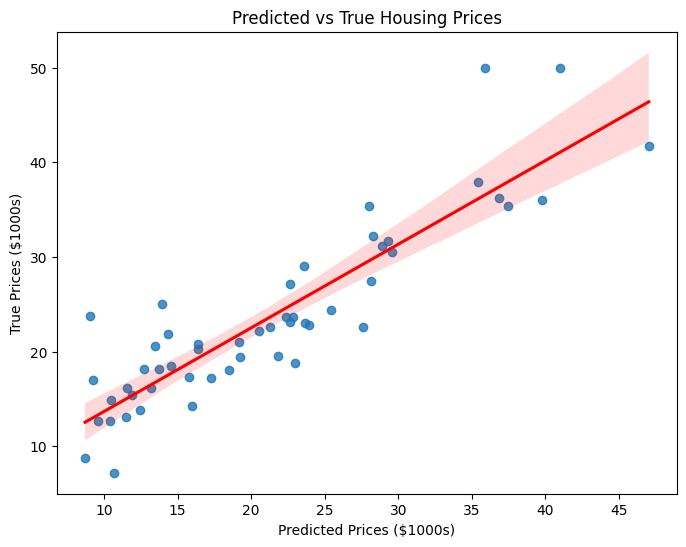

In [67]:
plt.figure(figsize=(8,6))
sns.regplot(x=preds, y=truths, line_kws={"color":"red"})
plt.xlabel("Predicted Prices ($1000s)")
plt.ylabel("True Prices ($1000s)")
plt.title("Predicted vs True Housing Prices")
plt.show()

What to look for:

Points close to the red line → model is accurate.

Points far from the line → large prediction errors.

# Visualizing errors helps understand:

1- Are we bad at expensive houses?

2- Are we biased?

3- Is variance increasing?

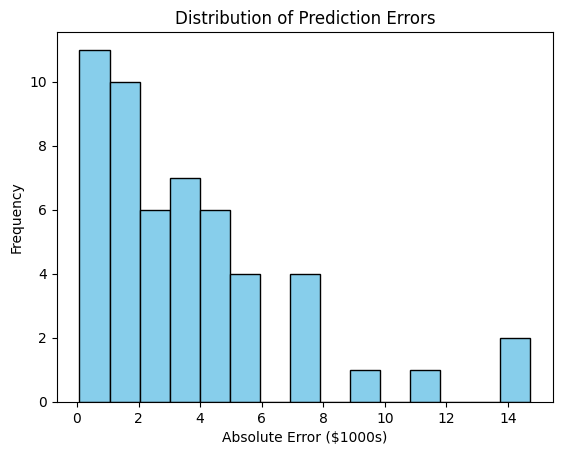

In [76]:

# Create a temporary DataFrame for plotting
df_errors = pd.DataFrame({
    "truth": truths,        # true house prices
    "prediction": preds     # predicted house prices
})

# Compute absolute errors
df_errors["error"] = abs(df_errors["truth"] - df_errors["prediction"])

# Plot histogram
plt.hist(df_errors["error"], bins=15, color='skyblue', edgecolor='black')
plt.xlabel("Absolute Error ($1000s)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()